# nb16 — одна позиция на символ (honest 8/3 на символ)

**Что это.** Ответ на конкретный вопрос: режим `8/3` — это 8% на памп-ногу и 3% на
дамп-ногу *от капитала*, но в движке `nb_best` доля применяется **per-position**, а не
**per-symbol**. Дедупликации по символу нет вообще (`sym` даже не заходит в движок),
поэтому на одном тикере могут висеть несколько пересекающихся позиций и риск на символ
уходит далеко за 8%. Здесь мы это (1) измеряем и (2) прогоняем честный вариант —
**одна позиция на символ**: пока на символе открыта позиция любой ноги, новый сигнал
блокируется (в т.ч. long поверх short запрещён). За счёт этого экспозиция на тикер
жёстко = 8%/3%.

**База.** Сигнальный слой и движок — 1:1 из `nb_best.ipynb` (эталон на 2026-07-07).
Меняется ровно одно: в `run_dca` добавлен флаг `onepos`. Никакого merge/усреднения —
оцениваем **по нижней границе** (чистый блок): бот часть заблокированных сигналов не
теряет, а вливает в открытую позицию, поэтому живой результат где-то между этим полом
и старым движком, но ближе к полу.

**Зачем.** Живой `pump_fade_bot` уже режет до ~одной позиции на символ (кулдаун 120м +
одна позиция на символ; см. сверку в `nb_best`, расхождение #2: из 144 kept-эвентов
эталона, которых нет у бота, 79 попали на уже открытую позицию — «влились/заблокированы»).
Значит старый движок завышает результат даже относительно собственного бота, а эта
таблица — честная модель того, что даёт живой счёт.


In [1]:
import sys; sys.path.insert(0, ".")
from _lab import show
import numpy as np, pandas as pd, heapq
from sklearn.ensemble import HistGradientBoostingRegressor
from scipy.optimize import brentq

# ── сигнальный слой (идентичен nb_best) ──────────────────────────────────────
PUMP = pd.read_parquet("_out/pump_rollover.parquet")
DUMP = pd.read_parquet("_out/dump_rollover.parquet")
GIVEBACKS = [0.005, 0.01, 0.02, 0.03, 0.05, 0.08, np.inf]
PUMP_G, DUMP_G = 6, 6          # hold-to-horizon (эталон)

PF = ["r1","r3","r5","r15","r30","accel5","surge15","surge1","rvol60","rng5","dist_hi240","dist_lo60"]
DF = ["r1","r3","r5","r15","r30","r60","accel","surge15","surge1","volreg","rng15","hi_d","lo_d","dstreak"]

def naive(s):
    s = pd.to_datetime(s)
    return s.dt.tz_localize(None) if s.dt.tz is not None else s

for D in (PUMP, DUMP):
    D["entry"] = naive(D["entry"])
    for i in range(len(GIVEBACKS)):
        D[f"exit{i}"] = naive(D[f"exit{i}"])

def wf_filter(df, feats, label):
    """Walk-forward HGBR (pump/14): экспандинг-окна 40/55/70/85/100%, торгуем pred>0."""
    pred = np.full(len(df), np.nan)
    cuts = [int(len(df)*q) for q in (0.40, 0.55, 0.70, 0.85, 1.0)]; prev = cuts[0]
    for cut in cuts[1:]:
        tr = df.iloc[:prev]
        m = HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05, max_iter=300,
            l2_regularization=1.0, min_samples_leaf=50, random_state=0).fit(tr[feats], tr[label])
        pred[prev:cut] = m.predict(df.iloc[prev:cut][feats]); prev = cut
    out = df.copy(); out["pred"] = pred
    return out[(pred > 0) | np.isnan(pred)]

pk = wf_filter(PUMP.assign(pnl=PUMP[f"pnl{PUMP_G}"], exit_ts=PUMP[f"exit{PUMP_G}"]), PF, "pnl")
dk = wf_filter(DUMP.assign(pnl=DUMP[f"pnl{DUMP_G}"], exit_ts=DUMP[f"exit{DUMP_G}"]), DF, "pnl")
BOOK = pd.concat([pk[["sym","entry","exit_ts","pnl","liq","stream","pred"]],
                  dk[["sym","entry","exit_ts","pnl","liq","stream","pred"]]]
                 ).sort_values("entry").reset_index(drop=True)
print(f"эталонная книга: {len(BOOK)} сделок  (pump {(BOOK.stream=='pump').sum()} / dump {(BOOK.stream=='dump').sum()})")
print(f"период: {BOOK.entry.min().date()} .. {BOOK.entry.max().date()}")


эталонная книга: 13000 сделок  (pump 9240 / dump 3760)
период: 2024-01-02 .. 2026-04-30


## Движок `run_dca` + флаг `onepos`

Тот же nb07/nb15_2 движок (DCA $1000 + $200/мес, ёмкость, слиппедж, ≤18 слотов,
резерв 10%). Единственное добавление — `onepos`:

- в heap кладём `sym`; при закрытии позиции символ уходит из множества `open_syms`;
- при `onepos=True` любой новый сигнал на символе из `open_syms` **пропускается**
  (`blocked_by_sym`), до того как считается доля/ёмкость. Это даёт «одну позицию на
  символ» и запрет long↔short на одном тикере.

`onepos=False` воспроизводит старый движок бит-в-бит.

In [2]:
# ── движок (nb07/nb15_2) + onepos ────────────────────────────────────────────
FILL_MIN = 30; PART_CAP = 0.10; SPREAD = 0.0010; IMPACT = 0.10

def run_dca(df, f_pump=0.05, f_dump=0.05, start=1000., monthly=200.,
            reserve=0.10, MAX=18, cap=True, slipmodel=True, onepos=False):
    """onepos=False → старый движок (нахлёст разрешён). onepos=True → одна позиция на символ."""
    en = df.entry.values.astype("datetime64[ns]"); ex = df.exit_ts.values.astype("datetime64[ns]")
    bpnl = df.pnl.values; liq = df.liq.values; stream = df.stream.values; sym = df.sym.values
    cap_no = PART_CAP * liq * FILL_MIN
    months = pd.date_range(pd.Timestamp(en.min()).normalize().replace(day=1),
                           pd.Timestamp(ex.max()), freq="MS")
    cash = start; contrib = start; dep = 0.; units = start; openh = []; mi = 0
    nav_t = [pd.Timestamp(en.min())]; nav_v = [1.0]; cf = [(-start, pd.Timestamp(en.min()))]
    taken = 0; skipped = 0; capped = 0; slip = 0.; trec = []; seq = 0
    open_syms = {}; blocked_by_sym = 0
    def snap(t):
        eq = cash + dep; nav_t.append(pd.Timestamp(t)); nav_v.append(eq/units)
    for i in range(len(bpnl)):
        now = pd.Timestamp(en[i])
        while mi < len(months) and months[mi] <= now:
            eq = cash + dep; nav = eq/units; units += monthly/nav; cash += monthly
            contrib += monthly; cf.append((-monthly, months[mi])); snap(months[mi]); mi += 1
        while openh and openh[0][0] <= en[i]:
            _, _s, no, pn, st, sy = heapq.heappop(openh); cash += no*(1+pn); dep -= no
            open_syms[sy] -= 1
            if open_syms[sy] == 0: del open_syms[sy]
            snap(_)
        eq = cash + dep
        if onepos and sym[i] in open_syms:            # ← honest per-symbol блок
            skipped += 1; blocked_by_sym += 1; continue
        f = f_pump if stream[i] == "pump" else f_dump
        desired = f*eq
        no = min(desired, cap_no[i]) if cap else desired
        if cap and no < desired - 1e-9: capped += 1
        if dep + no <= (1-reserve)*eq and len(openh) < MAX and cash >= no and no > 1:
            part = no/(liq[i]*FILL_MIN); sl = (SPREAD + IMPACT*part) if slipmodel else 0.0
            slip += no*sl; cash -= no; dep += no
            heapq.heappush(openh, (ex[i], seq, no, bpnl[i]-sl, stream[i], sym[i])); seq += 1
            open_syms[sym[i]] = open_syms.get(sym[i], 0) + 1; taken += 1
            trec.append((bpnl[i]-sl, no, stream[i])); snap(en[i])
        else:
            skipped += 1
    while mi < len(months):
        eq = cash + dep; nav = eq/units; units += monthly/nav; cash += monthly
        contrib += monthly; cf.append((-monthly, months[mi])); mi += 1
    for _, _s, no, pn, st, sy in sorted(openh): cash += no*(1+pn); dep -= no; snap(_)
    final = cash + dep; cf.append((final, pd.Timestamp(ex.max())))
    nav = pd.Series(nav_v, index=pd.to_datetime(nav_t)).sort_index()
    nav = nav[~nav.index.duplicated(keep="last")].resample("1D").last().ffill()
    tk = pd.DataFrame(trec, columns=["pnl", "notional", "stream"]); tk["usd"] = tk.notional*tk.pnl
    return dict(final=final, contrib=contrib, nav=nav, taken=taken, skipped=skipped,
                capped=capped, slip=slip, tk=tk, cf=cf, blocked_by_sym=blocked_by_sym)

def xirr(cf):
    amts = np.array([a for a, _ in cf]); ds = pd.to_datetime([d for _, d in cf])
    t = np.array([(d-ds[0]).days/365.25 for d in ds])
    try: return brentq(lambda r: np.sum(amts/(1+r)**t), -0.999, 100)
    except Exception: return np.nan

def metrics(R, tag):
    nav = R["nav"]; span = (nav.index[-1]-nav.index[0]).days/365.25
    rr = nav.pct_change().dropna(); sh = rr.mean()/rr.std()*np.sqrt(365)
    sor = rr.mean()/rr[rr < 0].std()*np.sqrt(365)
    dd = (nav.values/np.maximum.accumulate(nav.values)-1).min()
    cg = (nav.iloc[-1]/nav.iloc[0])**(1/span)-1
    tk = R["tk"]
    return dict(config=tag, final=f"${R['final']:,.0f}", mult=f"{R['final']/R['contrib']:.1f}x",
                CAGR=f"{cg*100:+.0f}%", Sharpe=f"{sh:.2f}", Sortino=f"{sor:.2f}", maxDD=f"{dd:.1%}",
                taken=R['taken'], blocked=R['blocked_by_sym'],
                capped=f"{R['capped']/max(R['taken'],1)*100:.0f}%", worst=f"{tk.pnl.min()*100:.0f}%")

print("движок готов")


движок готов


## Диагностика нахлёстов (сырая книга, без учёта сайзинга/слотов)

Сколько книги вообще держится на пересечениях позиций по одному символу — до всякого
сайзинга, чистая геометрия входов/выходов сигнального слоя.

In [3]:
def overlap_diag(df):
    en = df.entry.values.astype("datetime64[ns]"); ex = df.exit_ts.values.astype("datetime64[ns]")
    sym = df.sym.values; strm = df.stream.values
    openh = []; open_syms = {}; max_conc = {}; overlap_events = 0; ls_events = 0; cur_stream = {}
    order = np.argsort(en)
    for i in order:
        while openh and openh[0][0] <= en[i]:
            _, _s, sy = heapq.heappop(openh); open_syms[sy] -= 1
            if open_syms[sy] == 0: del open_syms[sy]; cur_stream.pop(sy, None)
        if sym[i] in open_syms:
            overlap_events += 1
            if sym[i] in cur_stream and cur_stream[sym[i]] != strm[i]: ls_events += 1
        open_syms[sym[i]] = open_syms.get(sym[i], 0) + 1
        cur_stream[sym[i]] = strm[i]
        max_conc[sym[i]] = max(max_conc.get(sym[i], 0), open_syms[sym[i]])
        heapq.heappush(openh, (ex[i], i, sym[i]))
    mc = pd.Series(max_conc)
    print(f"сигналов на уже открытой позиции того же символа: {overlap_events} "
          f"({overlap_events/len(df)*100:.1f}% книги)")
    print(f"  из них противоположная нога (long↔short на символе): {ls_events}")
    print(f"символов с >1 одновременной позицией хоть раз: {(mc>1).sum()} из {len(mc)}")
    print(f"макс. одновременных позиций на одном символе: {int(mc.max())} (символ {mc.idxmax()})")
    print("топ-8 символов по макс. одновременным позициям:")
    print(mc.sort_values(ascending=False).head(8).to_string())

overlap_diag(BOOK)


сигналов на уже открытой позиции того же символа: 4452 (34.2% книги)
  из них противоположная нога (long↔short на символе): 1964
символов с >1 одновременной позицией хоть раз: 171 из 172
макс. одновременных позиций на одном символе: 10 (символ PEOPLEUSDT)
топ-8 символов по макс. одновременным позициям:
PEOPLEUSDT      10
LUNA2USDT        8
1000BONKUSDT     8
SHIB1000USDT     8
1000LUNCUSDT     8
IOTXUSDT         7
COTIUSDT         7
CVXUSDT          7


## Лесенка режимов: нахлёст-разрешён [A] vs одна-позиция-на-символ [B]

`MODES` боевого бота (dump везде 3%, памп — ручка риска 3/4/5/8%). Две таблицы —
полный период и честное OOS-окно (с 40%-метки, где классификатор уже живёт).

In [4]:
TIERS = [("safe  pump3/dump3", 0.03, 0.03),
         ("med   pump4/dump3", 0.04, 0.03),
         ("agg   pump5/dump3", 0.05, 0.03),
         ("sagg  pump8/dump3", 0.08, 0.03)]

def compare(book, title):
    print(f"{'='*82}\n{title}\n{'='*82}")
    base = pd.DataFrame([metrics(run_dca(book, f_pump=fp, f_dump=fd, onepos=False), tag)
                         for tag, fp, fd in TIERS])
    one  = pd.DataFrame([metrics(run_dca(book, f_pump=fp, f_dump=fd, onepos=True), tag)
                         for tag, fp, fd in TIERS])
    print("\n[A] НАХЛЁСТ РАЗРЕШЁН (текущий движок nb_best):")
    print(base.to_string(index=False))
    print("\n[B] ОДНА ПОЗИЦИЯ НА СИМВОЛ (honest 8/3 на символ, блок long↔short):")
    print(one.to_string(index=False))
    return base, one

_ = compare(BOOK, f"ПОЛНЫЙ ПЕРИОД {BOOK.entry.min().date()}..{BOOK.entry.max().date()} — DCA $1000 + $200/мес")
print()
c0 = int(len(BOOK)*0.40)
OOS = BOOK.iloc[c0:].reset_index(drop=True)
_ = compare(OOS, f"OOS-ОКНО {OOS.entry.min().date()}..{OOS.entry.max().date()} ({len(OOS)} сделок)")


ПОЛНЫЙ ПЕРИОД 2024-01-02..2026-04-30 — DCA $1000 + $200/мес



[A] НАХЛЁСТ РАЗРЕШЁН (текущий движок nb_best):
           config   final mult  CAGR Sharpe Sortino  maxDD  taken  blocked capped worst
safe  pump3/dump3 $23,886 3.6x +128%   3.42    4.06 -10.7%   8873        0    12%  -38%
med   pump4/dump3 $29,573 4.5x +160%   3.42    3.84 -12.5%   8873        0    15%  -38%
agg   pump5/dump3 $34,970 5.3x +189%   3.31    3.58 -15.7%   8870        0    17%  -38%
sagg  pump8/dump3 $52,460 7.9x +270%   3.08    3.18 -23.7%   8580        0    25%  -38%

[B] ОДНА ПОЗИЦИЯ НА СИМВОЛ (honest 8/3 на символ, блок long↔short):
           config   final mult  CAGR Sharpe Sortino  maxDD  taken  blocked capped worst
safe  pump3/dump3 $15,652 2.4x  +83%   2.92    3.83  -8.5%   6549     2834    11%  -38%
med   pump4/dump3 $17,542 2.7x  +99%   2.99    3.67  -9.4%   6549     2834    13%  -38%
agg   pump5/dump3 $19,192 2.9x +113%   2.95    3.46 -11.1%   6544     2836    15%  -38%
sagg  pump8/dump3 $24,887 3.8x +159%   2.97    3.48 -14.9%   6407     2804    21%  -38%

OO


[A] НАХЛЁСТ РАЗРЕШЁН (текущий движок nb_best):
           config   final mult  CAGR Sharpe Sortino  maxDD  taken  blocked capped worst
safe  pump3/dump3 $17,263 3.1x +125%   3.55    4.15 -10.5%   5908        0    14%  -37%
med   pump4/dump3 $21,182 3.8x +160%   3.64    3.96 -12.0%   5908        0    17%  -37%
agg   pump5/dump3 $24,981 4.5x +191%   3.61    3.75 -14.2%   5906        0    20%  -37%
sagg  pump8/dump3 $37,246 6.7x +283%   3.46    3.43 -21.7%   5780        0    29%  -37%

[B] ОДНА ПОЗИЦИЯ НА СИМВОЛ (honest 8/3 на символ, блок long↔short):
           config   final mult  CAGR Sharpe Sortino  maxDD  taken  blocked capped worst
safe  pump3/dump3 $11,458 2.0x  +73%   2.71    3.64  -8.5%   4321     1749    13%  -37%
med   pump4/dump3 $12,555 2.2x  +86%   2.79    3.42  -9.4%   4321     1749    15%  -37%
agg   pump5/dump3 $13,608 2.4x  +98%   2.80    3.24 -10.9%   4320     1749    17%  -37%
sagg  pump8/dump3 $16,829 3.0x +136%   2.88    3.21 -15.8%   4249     1735    23%  -37%


## NAV: чемпион `sagg 8/3` — [A] vs [B]

Наглядно, сколько кривой держится на фантомных нахлёстах.

[saved] notebooks\pump_dump_combined\_out\comb_onepos_nav.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_combined/_out/comb_onepos_nav.png')

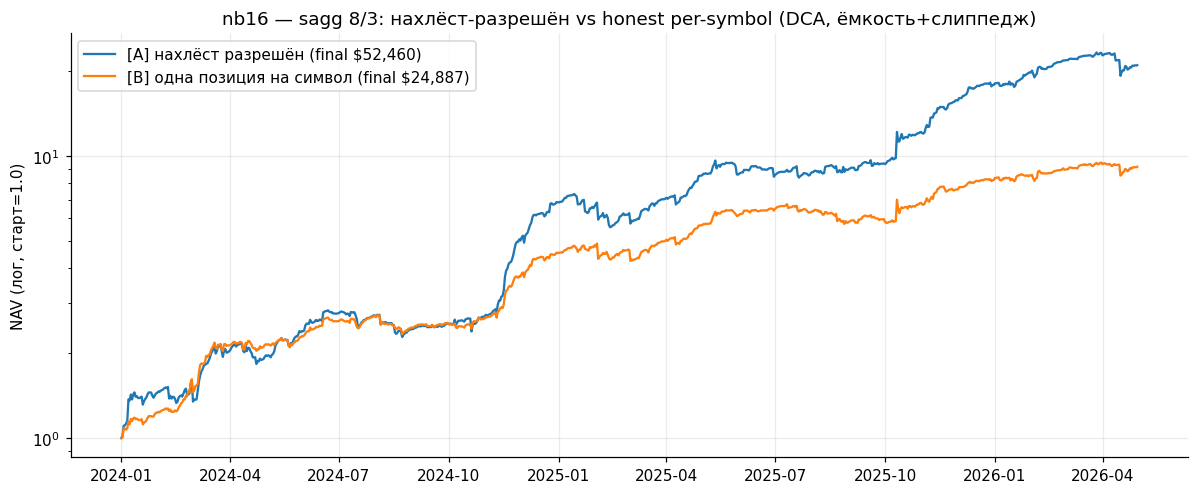

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(11, 4.6))
A = run_dca(BOOK, f_pump=0.08, f_dump=0.03, onepos=False)
B = run_dca(BOOK, f_pump=0.08, f_dump=0.03, onepos=True)
ax.plot(A["nav"].index, A["nav"].values, label=f"[A] нахлёст разрешён (final ${A['final']:,.0f})")
ax.plot(B["nav"].index, B["nav"].values, label=f"[B] одна позиция на символ (final ${B['final']:,.0f})")
ax.set_yscale("log"); ax.set_ylabel("NAV (лог, старт=1.0)"); ax.legend()
ax.set_title("nb16 — sagg 8/3: нахлёст-разрешён vs honest per-symbol (DCA, ёмкость+слиппедж)")
show("comb_onepos_nav")


## Вывод (честно)

- **~34% книги** — сигналы, попавшие на уже открытую позицию того же символа; из них
  ~2000 — противоположная нога (long↔short на одном тикере). Реальная концентрация на
  тикер доходила до 10 одновременных позиций (`PEOPLEUSDT`) — то есть ~80% эквити, а не 8%.
- **Примерно половина терминального капитала чемпиона `8/3` была сделана на этих
  нахлёстах.** OOS: `sagg` $37k → **$17k** (mult 6.7x → 3.0x, CAGR +283% → +136%).
  Живой счёт этого не воспроизведёт: бот и так режет до одной позиции на символ, а
  противоположные ноги на бирже неттятся / блокируются one-way режимом.

- **honest-cap чинит риск, а не только режет доход:** maxDD чемпиона −21.7% → −15.8%,
  Sharpe по всей лесенке выравнивается ~2.9 и почти не деградирует с ростом плеча
  (в [A] Sharpe валился с ростом размера). Экспозиция на тикер жёстко = 8%/3%.

- **Это нижняя граница.** Мы блокируем заблокированные сигналы полностью; бот часть из
  них вливает в открытую позицию (merge/усреднение), поэтому живой результат где-то
  между [B] и [A], но ближе к [B]. Merge здесь сознательно не моделируем — оцениваем по
  низу.

**Для бота.** Поведение «одна позиция на символ + блок» — не ограничение, а честная
модель. Таблица [B] — реалистичный потолок; старый движок [A] держать как эталон
опасно, он системно завышает.

**Ограничения честности (те же, что в nb_best).** In-sample потолок фильтра, стена
ёмкости (~$100k+), гэповый хвост дампа worst ≈ −37% при любом сайзинге, короткая
live-статистика.
